# Model Training, Cost Optimization & Selection

Trains baselines (dummy, logistic regression) and the two primary GBDT
candidates (LightGBM, XGBoost), then runs cost-sensitive threshold
optimization independently for each. Cost savings vs. a no-model baseline,
not AUC-ROC, decides the winner -- consistent with the project's decision
framework. Stacking and CNN-LSTM (Notebooks 04b/04c) are evaluated
separately on Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report, confusion_matrix
)
import lightgbm as lgb
import xgboost as xgb
import joblib

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120

# Load engineered dataset from Notebook 03
print('Loading engineered dataset...')
split_train = pd.read_parquet('../data/split_train_engineered.parquet')
split_test  = pd.read_parquet('../data/split_test_engineered.parquet')

print(f'split_train: {split_train.shape} | fraud rate: {split_train["isFraud"].mean():.2%}')
print(f'split_test:  {split_test.shape}  | fraud rate: {split_test["isFraud"].mean():.2%}')

Loading engineered dataset...
split_train: (472432, 374) | fraud rate: 3.51%
split_test:  (118108, 374)  | fraud rate: 3.44%


## Train/Test Split

Chronological 80/20 split (no shuffle): random shuffling would let the
model train on data from after the test period, leaking future information
and inflating validation scores relative to real deployment performance.


In [2]:
# Feature/target definition. The train/test split itself already happened
# in Notebook 01, before any feature engineering -- split_train and
# split_test are already in chronological order and leakage-free.

TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS = [c for c in DROP_COLS if c in split_train.columns]

obj_cols = split_train.select_dtypes('object').columns.tolist()
print(f'Dropping object columns: {obj_cols}')
DROP_COLS += obj_cols

FEATURES = [c for c in split_train.columns if c not in DROP_COLS]
print(f'Number of features: {len(FEATURES)}')

X_train, y_train = split_train[FEATURES], split_train[TARGET]
X_test, y_test    = split_test[FEATURES], split_test[TARGET]

print(f'\nTrain: {X_train.shape[0]:,} rows | Fraud rate: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape[0]:,} rows  | Fraud rate: {y_test.mean():.2%}')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f'\nscale_pos_weight: {SCALE_POS_WEIGHT:.1f} (neg/pos ratio)')

Dropping object columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
Number of features: 340

Train: 472,432 rows | Fraud rate: 3.51%
Test:  118,108 rows  | Fraud rate: 3.44%

scale_pos_weight: 27.5 (neg/pos ratio)


In [3]:
# ── Results tracker ───────────────────────────────────────────────────────────
# Store all model results here for final comparison table

results = {}

def evaluate_model(name, y_true, y_pred_proba, y_pred_binary=None):
    """Compute and store evaluation metrics for a model."""
    auc_roc = roc_auc_score(y_true, y_pred_proba)
    auc_pr  = average_precision_score(y_true, y_pred_proba)
    
    if y_pred_binary is None:
        y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    
    f1      = f1_score(y_true, y_pred_binary)
    recall  = (y_pred_binary[y_true == 1] == 1).mean()
    precision = (y_true[y_pred_binary == 1] == 1).mean() if y_pred_binary.sum() > 0 else 0
    
    results[name] = {
        'AUC-ROC': round(auc_roc, 4),
        'AUC-PR':  round(auc_pr, 4),
        'F1':      round(f1, 4),
        'Recall':  round(recall, 4),
        'Precision': round(precision, 4)
    }
    
    print(f'\n=== {name} ===')
    print(f'  AUC-ROC:   {auc_roc:.4f}')
    print(f'  AUC-PR:    {auc_pr:.4f}')
    print(f'  F1:        {f1:.4f}')
    print(f'  Recall:    {recall:.4f}')
    print(f'  Precision: {precision:.4f}')
    return results[name]

## Baselines

B0 (dummy) always predicts "no fraud" -- 96.5% accuracy but zero fraud
caught, the floor any useful model must beat. B1 (logistic regression) is
a simple linear baseline without UID aggregation features.

In [4]:
# ── B0: Dummy Classifier ──────────────────────────────────────────────────────

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

# Dummy always predicts 0 -> proba is always [1.0, 0.0]
# AUC-ROC needs some variation, so we use predict_proba
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_pred  = dummy.predict(X_test)

print(f'Dummy always predicts: {dummy.predict(X_test[:5])}')
print(f'Accuracy: {(dummy_pred == y_test).mean():.2%} (misleading!)')
print(f'Fraud caught: {(dummy_pred[y_test == 1] == 1).sum()} / {(y_test == 1).sum()}')

evaluate_model('B0_Dummy', y_test, dummy_proba, dummy_pred)

Dummy always predicts: [0 0 0 0 0]
Accuracy: 96.56% (misleading!)
Fraud caught: 0 / 4064

=== B0_Dummy ===
  AUC-ROC:   0.5000
  AUC-PR:    0.0344
  F1:        0.0000
  Recall:    0.0000
  Precision: 0.0000


{'AUC-ROC': 0.5,
 'AUC-PR': 0.0344,
 'F1': 0.0,
 'Recall': np.float64(0.0),
 'Precision': 0}

In [5]:
# ── B1: Logistic Regression ───────────────────────────────────────────────────

# Scale features (LR requires normalized input)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_test_scaled  = scaler.transform(X_test.fillna(0))

lr = LogisticRegression(
    C=0.1,                          # L2 regularization
    class_weight='balanced',        # handles imbalance
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print('Training Logistic Regression...')
lr.fit(X_train_scaled, y_train)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred  = lr.predict(X_test_scaled)

evaluate_model('B1_LogisticRegression', y_test, lr_proba, lr_pred)

Training Logistic Regression...

=== B1_LogisticRegression ===
  AUC-ROC:   0.8236
  AUC-PR:    0.1761
  F1:        0.1792
  Recall:    0.7370
  Precision: 0.1020


{'AUC-ROC': 0.8236,
 'AUC-PR': 0.1761,
 'F1': 0.1792,
 'Recall': np.float64(0.737),
 'Precision': np.float64(0.102)}

## LightGBM

`scale_pos_weight` handles class imbalance natively; early stopping
prevents overfitting on the validation set.


In [6]:
lgbm_params = {
    'objective':        'binary',
    'metric':           ['auc', 'average_precision'],
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       64,
    'max_depth':        -1,
    'min_child_samples': 20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1
}

lgbm_model = lgb.LGBMClassifier(**lgbm_params)

print('Training LightGBM...')
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_pred  = lgbm_model.predict(X_test)

evaluate_model('C1a_LightGBM', y_test, lgbm_proba, lgbm_pred)

# Save model
joblib.dump(lgbm_model, '../models/lgbm_model.pkl')
print('\nModel saved: models/lgbm_model.pkl')

Training LightGBM...
[100]	valid_0's auc: 0.906347	valid_0's average_precision: 0.490345
[200]	valid_0's auc: 0.913842	valid_0's average_precision: 0.520713

=== C1a_LightGBM ===
  AUC-ROC:   0.9147
  AUC-PR:    0.5239
  F1:        0.3320
  Recall:    0.7581
  Precision: 0.2125

Model saved: models/lgbm_model.pkl


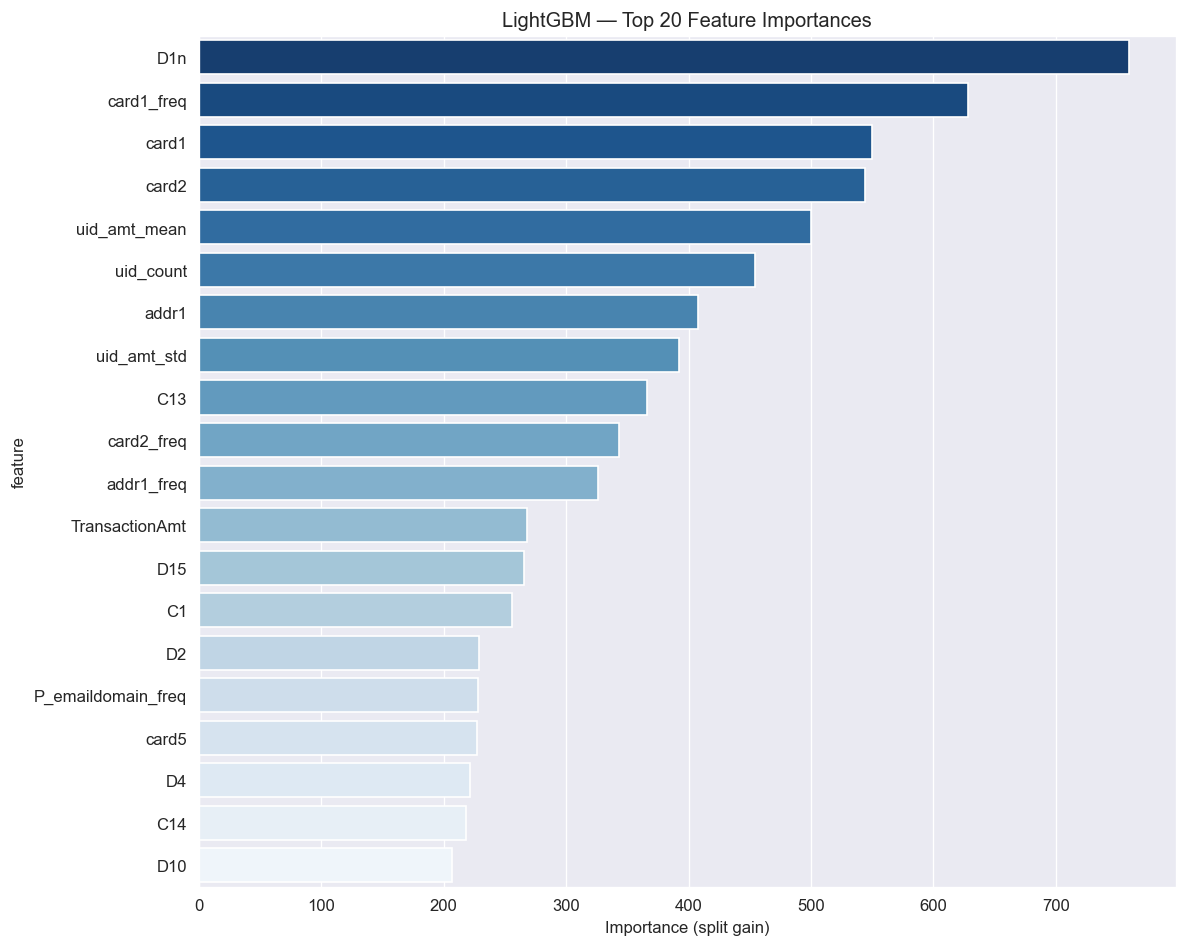

Top 10 features:
     feature  importance
         D1n         760
  card1_freq         628
       card1         550
       card2         544
uid_amt_mean         500
   uid_count         454
       addr1         408
 uid_amt_std         392
         C13         366
  card2_freq         343


In [7]:
# ── LightGBM Feature Importance ───────────────────────────────────────────────

feat_imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature',
            palette='Blues_r', ax=ax)
ax.set_title('LightGBM — Top 20 Feature Importances')
ax.set_xlabel('Importance (split gain)')
plt.tight_layout()
plt.savefig('../reports/lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string(index=False))

## XGBoost

Second GBDT candidate. Slightly slower than LightGBM but often more robust on smaller datasets.
Key question: does XGBoost outperform LightGBM on this dataset?


In [8]:
xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      ['auc', 'aucpr'],
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'max_depth':        6,
    'min_child_weight': 5,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'n_jobs':           -1,
    'tree_method':      'hist',   # fast histogram method, no GPU needed
    'early_stopping_rounds': 50 
}

xgb_model = xgb.XGBClassifier(**xgb_params)

print('Training XGBoost...')
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

evaluate_model('C1b_XGBoost', y_test, xgb_proba, xgb_pred)

joblib.dump(xgb_model, '../models/xgb_model.pkl')
print('\nModel saved: models/xgb_model.pkl')

Training XGBoost...
[0]	validation_0-auc:0.82615	validation_0-aucpr:0.31215
[100]	validation_0-auc:0.89150	validation_0-aucpr:0.47100
[200]	validation_0-auc:0.90310	validation_0-aucpr:0.49821
[300]	validation_0-auc:0.90729	validation_0-aucpr:0.50954
[400]	validation_0-auc:0.90820	validation_0-aucpr:0.51581
[500]	validation_0-auc:0.91010	validation_0-aucpr:0.52448
[600]	validation_0-auc:0.91169	validation_0-aucpr:0.53322
[700]	validation_0-auc:0.91131	validation_0-aucpr:0.53604
[800]	validation_0-auc:0.91184	validation_0-aucpr:0.54087
[900]	validation_0-auc:0.91269	validation_0-aucpr:0.54560
[999]	validation_0-auc:0.91173	validation_0-aucpr:0.55042

=== C1b_XGBoost ===
  AUC-ROC:   0.9117
  AUC-PR:    0.5505
  F1:        0.4324
  Recall:    0.6690
  Precision: 0.3195

Model saved: models/xgb_model.pkl


## Results Comparison Table


In [9]:
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

# External benchmark -- preprint, not peer-reviewed (see report Section 4.1)
benchmark = pd.DataFrame({
    'Moradi_et_al_2025': {'AUC-ROC': 0.918, 'AUC-PR': 0.891, 'F1': None, 'Recall': None, 'Precision': None}
}).T

all_results = pd.concat([results_df, benchmark])
print('\n=== Model Comparison (local candidates) ===')
print(all_results.to_string())
print('\nNote: Stacking (Notebook 04b) and CNN-LSTM (Notebook 04c) results are')
print('reported separately, since they run on Google Colab. Final model')
print('selection (Section 4.7 of the report) is based on cost savings and')
print('measured inference latency, not on AUC-ROC alone.')


=== Model Comparison (local candidates) ===
                       AUC-ROC  AUC-PR      F1  Recall  Precision
B0_Dummy                0.5000  0.0344  0.0000  0.0000     0.0000
B1_LogisticRegression   0.8236  0.1761  0.1792  0.7370     0.1020
C1a_LightGBM            0.9147  0.5239  0.3320  0.7581     0.2125
C1b_XGBoost             0.9117  0.5505  0.4324  0.6690     0.3195
Moradi_et_al_2025       0.9180  0.8910     NaN     NaN        NaN

Note: Stacking (Notebook 04b) and CNN-LSTM (Notebook 04c) results are
reported separately, since they run on Google Colab. Final model
selection (Section 4.7 of the report) is based on cost savings and
measured inference latency, not on AUC-ROC alone.


## Cost-Sensitive Threshold Optimization

Default threshold (0.5) optimizes for accuracy, which is meaningless under
3.5% class imbalance. The decision threshold is instead swept to minimize
total expected cost (FN = transaction amount, FP = $10), run independently
for each candidate so the winner is chosen by cost savings -- not AUC-ROC.


In [10]:
COST_FP = 10     # False Positive: customer friction ($)
COST_FN = 150    # False Negative: average fraud loss ($) -- informational only,
                 # actual FN cost below uses the real TransactionAmt per row

test_amounts = split_test['TransactionAmt'].values
no_model_cost = test_amounts[y_test.values == 1].sum()

def optimize_threshold(proba, y_true, amounts, cost_fp=10):
    """Sweep thresholds, return (thresholds, total_costs, f1_scores, optimal_idx)."""
    thresholds  = np.arange(0.05, 0.95, 0.01)
    total_costs = []
    f1_scores_sweep = []

    for thresh in thresholds:
        preds = (proba >= thresh).astype(int)
        fn_mask = (preds == 0) & (y_true.values == 1)
        fn_cost = amounts[fn_mask].sum()
        fp_mask = (preds == 1) & (y_true.values == 0)
        fp_cost = fp_mask.sum() * cost_fp
        total_costs.append(fn_cost + fp_cost)
        f1_scores_sweep.append(f1_score(y_true, preds))

    total_costs = np.array(total_costs)
    optimal_idx = np.argmin(total_costs)
    return thresholds, total_costs, f1_scores_sweep, optimal_idx

cost_results = {}

for model_name, proba in [('LightGBM', lgbm_proba), ('XGBoost', xgb_proba)]:
    thresholds, total_costs, f1_scores_sweep, optimal_idx = optimize_threshold(
        proba, y_test, test_amounts, COST_FP
    )
    optimal_thresh = thresholds[optimal_idx]
    optimal_cost   = total_costs[optimal_idx]
    savings        = no_model_cost - optimal_cost
    savings_pct    = savings / no_model_cost * 100

    cost_results[model_name] = {
        'thresholds': thresholds, 'total_costs': total_costs,
        'f1_scores_sweep': f1_scores_sweep, 'optimal_idx': optimal_idx,
        'optimal_thresh': optimal_thresh, 'optimal_cost': optimal_cost,
        'savings': savings, 'savings_pct': savings_pct, 'proba': proba
    }

    print(f'=== {model_name} ===')
    print(f'  Optimal threshold:    {optimal_thresh:.2f}')
    print(f'  Total cost at optimal: ${optimal_cost:,.0f}')
    print(f'  Savings:               ${savings:,.0f} ({savings_pct:.1f}%)')
    print()

print(f'No-model baseline cost: ${no_model_cost:,.0f}')
print()

# Final model selection: whichever has higher cost savings wins, since cost
# savings (not AUC-ROC) is this project\'s primary, business-facing metric.
winner = max(cost_results, key=lambda k: cost_results[k]['savings'])
print(f'>>> WINNER by cost savings: {winner} '
      f'(${cost_results[winner]["savings"]:,.0f}, {cost_results[winner]["savings_pct"]:.1f}%)')

best_proba      = cost_results[winner]['proba']
optimal_thresh  = cost_results[winner]['optimal_thresh']
optimal_cost    = cost_results[winner]['optimal_cost']
savings         = cost_results[winner]['savings']
savings_pct     = cost_results[winner]['savings_pct']
thresholds      = cost_results[winner]['thresholds']
total_costs     = cost_results[winner]['total_costs']
f1_scores_sweep = cost_results[winner]['f1_scores_sweep']


=== LightGBM ===
  Optimal threshold:    0.49
  Total cost at optimal: $282,536
  Savings:               $327,398 (53.7%)

=== XGBoost ===
  Optimal threshold:    0.32
  Total cost at optimal: $287,236
  Savings:               $322,698 (52.9%)

No-model baseline cost: $609,934

>>> WINNER by cost savings: LightGBM ($327,398, 53.7%)


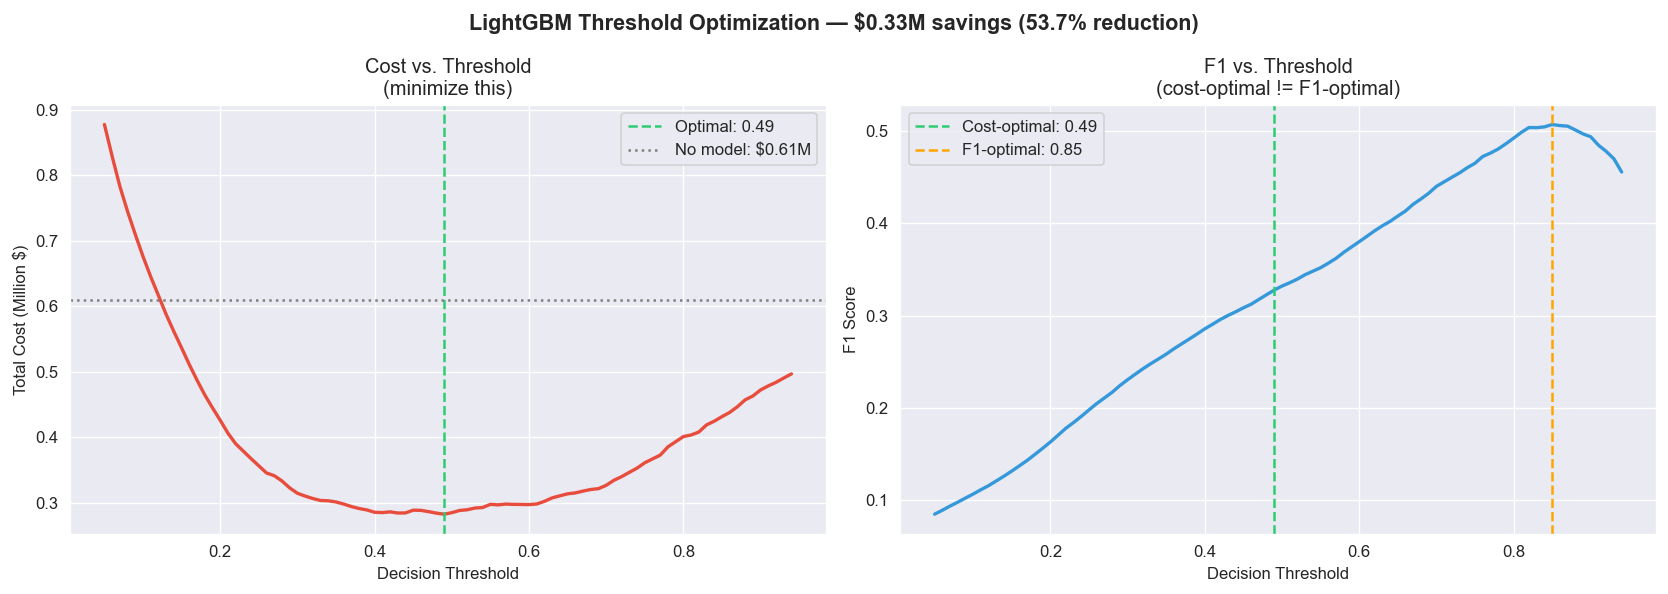

Saved: reports/threshold_optimization.png

Final model selected by cost savings: LightGBM


In [11]:
# ── Plot: Cost vs Threshold (winning model) ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total cost vs threshold
axes[0].plot(thresholds, total_costs / 1e6, color='#e74c3c', linewidth=2)
axes[0].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Optimal: {optimal_thresh:.2f}')
axes[0].axhline(no_model_cost / 1e6, color='gray', linestyle=':',
                label=f'No model: ${no_model_cost/1e6:.2f}M')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (Million $)')
axes[0].set_title('Cost vs. Threshold\n(minimize this)')
axes[0].legend()

# Right: F1 vs threshold
axes[1].plot(thresholds, f1_scores_sweep, color='#3498db', linewidth=2)
axes[1].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Cost-optimal: {optimal_thresh:.2f}')
f1_optimal_idx = np.argmax(f1_scores_sweep)
axes[1].axvline(thresholds[f1_optimal_idx], color='orange', linestyle='--',
                label=f'F1-optimal: {thresholds[f1_optimal_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs. Threshold\n(cost-optimal != F1-optimal)')
axes[1].legend()

plt.suptitle(f'{winner} Threshold Optimization — ${savings/1e6:.2f}M savings ({savings_pct:.1f}% reduction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/threshold_optimization.png')
print(f'\nFinal model selected by cost savings: {winner}')


=== Final Performance at Optimal Threshold (0.49) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94    114044
       Fraud       0.21      0.76      0.33      4064

    accuracy                           0.89    118108
   macro avg       0.60      0.83      0.63    118108
weighted avg       0.96      0.89      0.92    118108



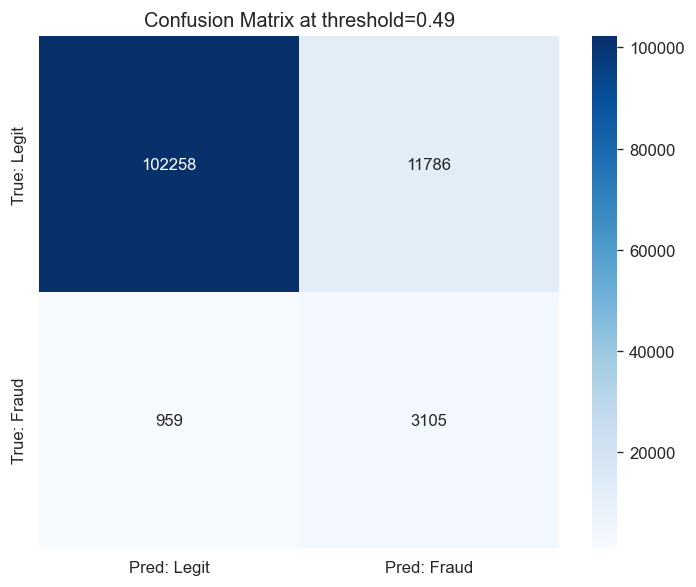

In [12]:
# ── Final evaluation at optimal threshold ─────────────────────────────────────

optimal_preds = (best_proba >= optimal_thresh).astype(int)

print(f'=== Final Performance at Optimal Threshold ({optimal_thresh:.2f}) ===')
print(classification_report(y_test, optimal_preds,
                             target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_test, optimal_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['True: Legit', 'True: Fraud'], ax=ax)
ax.set_title(f'Confusion Matrix at threshold={optimal_thresh:.2f}')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()